# FastAPI

### What is fastapi?

FastAPI is a modern Python web framework for building APIs. It is designed for speed, developer productivity, and clear code. It uses Python type hints to provide automatic validation and interactive documentation.

### key features of fastapi:

* **High Performance** – Built on modern Python features and is one of the fastest Python web frameworks.
* **Automatic API Documentation** – Generates interactive API docs (Swagger UI and ReDoc) automatically.
* **Data Validation** – Uses Pydantic to validate request and response data automatically, reducing errors and boilerplate   code.

### How FastAPI differs from other frameworks

* **Flask**: Minimal and synchronous by default. FastAPI adds automatic validation, async support, and docs with less configuration.
* **Django**: Full-stack framework with ORM, templating, and admin. FastAPI focuses on APIs and is much lighter for service endpoints.
* **FastAPI**: Best for API-first projects where speed, schema validation, and documentation matter.

## Installation and setup

Use pip to install the FastAPI framework:


In [ ]:
pip install fastapi

FastAPI needs an ASGI server to run. The most common and recommended one is Uvicorn. So, run the following command in terminal:

In [ ]:
pip install uvicorn

### Why uvicorn is needed?

Without Uvicorn, FastAPI only defines the API logic; Uvicorn actually starts the web server, listens for requests, and sends responses back to clients.

### creating fastapi app:

In [ ]:
from fastapi import FastAPI

# Create FastAPI app instance
app = FastAPI()

# Define a simple GET endpoint
@app.get("/")
def health_check():
    return {"message": "yes i'm working"}

### How to run fastapi app

In [ ]:
uvicorn main:app --reload

### What is App Instance?

The app instance is the main object of a FastAPI application. It acts as the entry point where you define routes, middleware, event handlers, and application configurations.

In [ ]:
app.include_router()
app.add_middleware()

### What is Dependency Injection?

Dependency Injection is a way to provide or inject required data, objects, or services into an API endpoint instead of creating them inside the endpoint.

#### For example, 
In role-based authentication (Admin/User), an endpoint may need information about the currently logged-in user. Using Dependency Injection, FastAPI automatically provides that user information to the endpoint, which can then be used to check permissions and access.

In [ ]:
from fastapi import Depends, FastAPI

app = FastAPI()

count = 0

def get_current_role():
    global count
    count += 1
    print(f"Called {count} times")
    return "admin"

@app.get("/users")
def get_users(role=Depends(get_current_role)):
    return {"role": role}


### Differece between Decorator and Dependancy Injection

#### Decorator:

Use decorators when you want to execute some common logic before or after a function (change its behavior).

Examples:

- Logging API requests
- Custom permission checks
- Error handling

#### Dependency Injection (Depends):

Use Dependency Injection when your endpoint needs some data or service to perform its work.

Examples:

- Database connection
- Current logged-in user
- Common validation logic

### Model Creation in FastAPI

In FastAPI, models are usually created using Pydantic's BaseModel. These models define the structure, data types, and validation rules for request and response data.

In [ ]:
from pydantic import BaseModel

class User(BaseModel):
    name: str
    age: int
    email: str

### What is Pydantic?

Pydantic is a Python library used to validate, parse, and serialize data using Python classes.

In FastAPI, Pydantic is used to validate request data automatically before it reaches your endpoint.

In [ ]:
from pydantic import BaseModel

class User(BaseModel):
    name: str | None = None
    age: int | None = None

### What is Middleware?

Middleware is code that runs before and/or after every request reaches your API endpoint.

It acts as a layer between the client request and your API.

Some use case:

- CORS handling
- Security headers
- Global authentication checks
- Rate limiting

In [ ]:
from fastapi import FastAPI, Request

app = FastAPI()

@app.middleware("http")
async def log_requests(request: Request, call_next):
    print("Request received")

    response = await call_next(request)

    print("Response sent")
    return response

## App Structure - FastAPI Folder Structure

A common FastAPI layout keeps code organized by feature. Below is a simple structure for a small project.

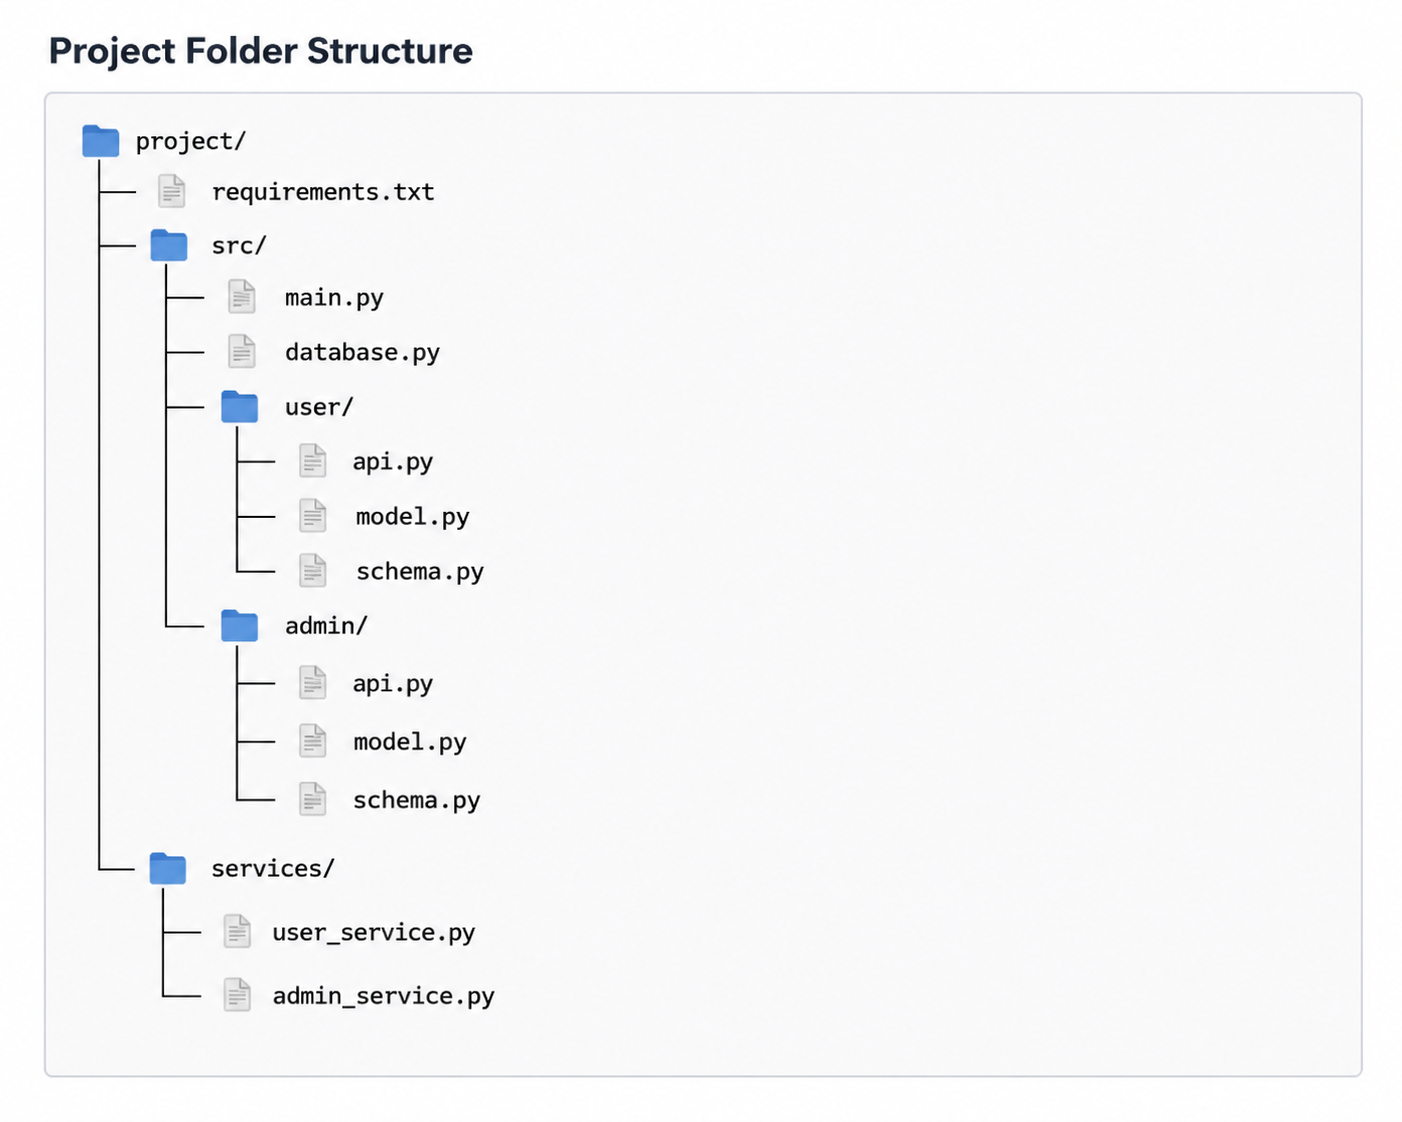

### What is a Background Job in FastAPI?

A Background Job is a task that runs after the API sends a response to the client.

This helps the user get a response quickly without waiting for long-running tasks to finish.

In [ ]:
# @app.post("/send-email")
# def send_email():
#     # Takes 10 seconds
#     send_email_to_user()

#     return {"message": "Email Sent"}

from fastapi import FastAPI, BackgroundTasks

app = FastAPI()

def send_email():
    print("Sending email...")

@app.post("/send-email")
def send_email_api(background_tasks: BackgroundTasks):

    background_tasks.add_task(send_email)

    return {"message": "Email request received"}